<a href="https://colab.research.google.com/github/RyanLiuQc/food-recipe-generation/blob/main/FoodRecipe.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
from google.colab import userdata

# Safely fetch the secrets from your Colab account
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

# Download the dataset
!kaggle datasets download -d sarthak71/food-recipes
!unzip -q food-recipes.zip

Dataset URL: https://www.kaggle.com/datasets/sarthak71/food-recipes
License(s): other
100% 5.32M/5.32M [00:02<00:00, 2.29MB/s]



In [4]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer
from tqdm import tqdm

In [5]:
df = pd.read_csv("food_recipes.csv")

print(len(df))

# drop rows with empty 'recipe_title', 'ingredients' and 'instructions'
df = df.dropna(subset=['recipe_title', 'ingredients', 'instructions'])

print(len(df))

df.head()

8009
7997


,recipe_title,url,record_health,vote_count,rating,description,cuisine,course,diet,prep_time,cook_time,ingredients,instructions,author,tags,category
0,Roasted Peppers And Mushroom Tortilla Pizza Re...,https://www.archanaskitchen.com/roasted-pepper...,good,434,4.958525,is a quicker version pizza to satisfy your cr...,Mexican,Dinner,Vegetarian,15 M,15 M,Tortillas|Extra Virgin Olive Oil|Garlic|Mozzar...,To begin making the Roasted Peppers And Mushro...,Divya Shivaraman,Party Food Recipes|Tea Party Recipes|Mushroom ...,Pizza Recipes
1,Thakkali Gotsu Recipe | Thakkali Curry | Spicy...,https://www.archanaskitchen.com/tomato-gotsu-r...,good,3423,4.932223,also known as the is a quick and easy to ma...,South Indian Recipes,Lunch,Vegetarian,10 M,20 M,Sesame (Gingelly) Oil|Mustard seeds (Rai/ Kadu...,To begin making Tomato Gotsu Recipe/ Thakkali ...,Archana Doshi,Vegetarian Recipes|Tomato Recipes|South Indian...,Indian Curry Recipes
2,Spicy Grilled Pineapple Salsa Recipe,https://www.archanaskitchen.com/spicy-grilled-...,good,2091,4.945959,Spicy Grilled Pineapple Salsa is a simple reci...,Mexican,Side Dish,Vegetarian,10 M,0 M,Extra Virgin Olive Oil|Pineapple|White onion|R...,To begin making the Spicy Grilled Pineapple Sa...,Archana's Kitchen,Party Starter & Appetizer Recipes|Pineapple Re...,Mexican Recipes
3,Karwar Style Dali Thoy Recipe - Toor dal Curry,https://www.archanaskitchen.com/dali-thoy-reci...,good,990,4.888889,The is a quintessential of Konkani dish whic...,Coastal Karnataka,Side Dish,High Protein Vegetarian,5 M,20 M,Arhar dal (Split Toor Dal)|Turmeric powder (Ha...,To prepare Karwar Style Dali Thoy Recipe (Toor...,Jyothi Rajesh,Side Dish Recipes|South Indian Recipes|Indian ...,Indian Curry Recipes
4,Rajma Kofta In Milk And Poppy Seed Gravy Recipe,https://www.archanaskitchen.com/rajma-kofta-in...,good,345,4.828986,Koftas are traditional Indian recipes mostly w...,North Indian Recipes,Side Dish,High Protein Vegetarian,20 M,30 M,Rajma (Large Kidney Beans)|Cashew nuts|Sultana...,To begin making Rajma Kofta In Milk And Poppy ...,RUBY PATHAK,Side Dish Recipes|Indian Lunch Recipes|Office ...,Kofta Recipes


In [6]:
def format_recipe(row):
    """
    Converts the pipe-delimited CSV columns into a clean, readable string
    with distinct sections for the model to learn from.
    """
    title = row['recipe_title']

    # Split the string by '|' and create a bulleted list
    ingredients_list = row['ingredients'].split('|')
    ingredients_str = "\n".join([f"• {ing.strip()}" for ing in ingredients_list])

    # Split the instructions by '|' and create a numbered/bulleted list
    instructions_list = row['instructions'].split('|')
    instructions_str = "\n".join([f"▪︎ {inst.strip()}" for inst in instructions_list])

    # Combine everything using visual landmarks (Emojis act as section tokens)
    # The '␣' acts as an End-of-Recipe token
    recipe_text = f"📗 {title}\n🥕\n{ingredients_str}\n📝\n{instructions_str}\n␣"

    return recipe_text

In [7]:
# only necessary rows
df = df[['recipe_title', 'ingredients', 'instructions']]

df['formatted_recipe'] = df.apply(format_recipe, axis=1)

df

,recipe_title,ingredients,instructions,formatted_recipe
0,Roasted Peppers And Mushroom Tortilla Pizza Re...,Tortillas|Extra Virgin Olive Oil|Garlic|Mozzar...,To begin making the Roasted Peppers And Mushro...,📗 Roasted Peppers And Mushroom Tortilla Pizza ...
1,Thakkali Gotsu Recipe | Thakkali Curry | Spicy...,Sesame (Gingelly) Oil|Mustard seeds (Rai/ Kadu...,To begin making Tomato Gotsu Recipe/ Thakkali ...,📗 Thakkali Gotsu Recipe | Thakkali Curry | Spi...
2,Spicy Grilled Pineapple Salsa Recipe,Extra Virgin Olive Oil|Pineapple|White onion|R...,To begin making the Spicy Grilled Pineapple Sa...,📗 Spicy Grilled Pineapple Salsa Recipe\n🥕\n• E...
3,Karwar Style Dali Thoy Recipe - Toor dal Curry,Arhar dal (Split Toor Dal)|Turmeric powder (Ha...,To prepare Karwar Style Dali Thoy Recipe (Toor...,📗 Karwar Style Dali Thoy Recipe - Toor dal Cur...
4,Rajma Kofta In Milk And Poppy Seed Gravy Recipe,Rajma (Large Kidney Beans)|Cashew nuts|Sultana...,To begin making Rajma Kofta In Milk And Poppy ...,📗 Rajma Kofta In Milk And Poppy Seed Gravy Rec...
...,...,...,...,...
8004,Zucchini and Carrot Pasta Recipe,Spirali pasta|Onions|Tomatoes|Green zucchini|C...,To begin with Zucchini And Carrot Pasta Recipe...,📗 Zucchini and Carrot Pasta Recipe\n🥕\n• Spira...
8005,Hyderabadi Khatti Dal Recipe (Hyderabadi Tangy...,Arhar dal (Split Toor Dal)|Tomato|Turmeric pow...,To begin making the Hyderabadi Khatti Dal Reci...,📗 Hyderabadi Khatti Dal Recipe (Hyderabadi Tan...
8006,Karwar Style Muga Ambat Recipe (Moong Sprouts ...,Turmeric powder (Haldi)|Sugar|Salt|Fresh cocon...,To prepare Karwar Style Muga Ambat Recipe (Moo...,📗 Karwar Style Muga Ambat Recipe (Moong Sprout...
8007,"Beetroot, Amla And Pudina Juice Recipe | Mint ...",Beetroot|Amla (Nellikai/ Gooseberry)|Mint Leav...,"To begin making the Beetroot, Amla And Pudina...","📗 Beetroot, Amla And Pudina Juice Recipe | Min..."


In [8]:
df['text_len'] = df['formatted_recipe'].apply(len)

df

,recipe_title,ingredients,instructions,formatted_recipe,text_len
0,Roasted Peppers And Mushroom Tortilla Pizza Re...,Tortillas|Extra Virgin Olive Oil|Garlic|Mozzar...,To begin making the Roasted Peppers And Mushro...,📗 Roasted Peppers And Mushroom Tortilla Pizza ...,1099
1,Thakkali Gotsu Recipe | Thakkali Curry | Spicy...,Sesame (Gingelly) Oil|Mustard seeds (Rai/ Kadu...,To begin making Tomato Gotsu Recipe/ Thakkali ...,📗 Thakkali Gotsu Recipe | Thakkali Curry | Spi...,1377
2,Spicy Grilled Pineapple Salsa Recipe,Extra Virgin Olive Oil|Pineapple|White onion|R...,To begin making the Spicy Grilled Pineapple Sa...,📗 Spicy Grilled Pineapple Salsa Recipe\n🥕\n• E...,1115
3,Karwar Style Dali Thoy Recipe - Toor dal Curry,Arhar dal (Split Toor Dal)|Turmeric powder (Ha...,To prepare Karwar Style Dali Thoy Recipe (Toor...,📗 Karwar Style Dali Thoy Recipe - Toor dal Cur...,857
4,Rajma Kofta In Milk And Poppy Seed Gravy Recipe,Rajma (Large Kidney Beans)|Cashew nuts|Sultana...,To begin making Rajma Kofta In Milk And Poppy ...,📗 Rajma Kofta In Milk And Poppy Seed Gravy Rec...,1686
...,...,...,...,...,...
8004,Zucchini and Carrot Pasta Recipe,Spirali pasta|Onions|Tomatoes|Green zucchini|C...,To begin with Zucchini And Carrot Pasta Recipe...,📗 Zucchini and Carrot Pasta Recipe\n🥕\n• Spira...,969
8005,Hyderabadi Khatti Dal Recipe (Hyderabadi Tangy...,Arhar dal (Split Toor Dal)|Tomato|Turmeric pow...,To begin making the Hyderabadi Khatti Dal Reci...,📗 Hyderabadi Khatti Dal Recipe (Hyderabadi Tan...,1665
8006,Karwar Style Muga Ambat Recipe (Moong Sprouts ...,Turmeric powder (Haldi)|Sugar|Salt|Fresh cocon...,To prepare Karwar Style Muga Ambat Recipe (Moo...,📗 Karwar Style Muga Ambat Recipe (Moong Sprout...,1287
8007,"Beetroot, Amla And Pudina Juice Recipe | Mint ...",Beetroot|Amla (Nellikai/ Gooseberry)|Mint Leav...,"To begin making the Beetroot, Amla And Pudina...","📗 Beetroot, Amla And Pudina Juice Recipe | Min...",980


In [9]:
import matplotlib.pyplot as plt


(array([ 33., 100., 313., 497., 642., 744., 766., 789., 740., 655., 560.,
        461., 337., 280., 256., 177., 140., 112.,  78.,  67.,  59.,  44.,
         33.,  24.,  19.,  14.,  15.,  11.,   8.,   5.,   4.,   6.,   1.,
          2.,   1.,   1.,   2.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   1.]),
 array([ 315.  ,  429.96,  544.92,  659.88,  774.84,  889.8 , 1004.76,
        1119.72, 1234.68, 1349.64, 1464.6 , 1579.56, 1694.52, 1809.48,
        1924.44, 2039.4 , 2154.36, 2269.32, 2384.28, 2499.24, 2614.2 ,
        2729.16, 2844.12, 2959.08, 3074.04, 3189.  , 3303.96, 3418.92,
        3533.88, 3648.84, 3763.8 , 3878.76, 3993.72, 4108.68, 4223.64,
        4338.6 , 4453.56, 4568.52, 4683.48, 4798.44, 4913.4 , 5028.36,
        5143.32, 5258.28, 5373.24, 5488.2 , 5603.16, 5718.12, 5833.08,
        5948.04, 6063.  ]),
 <BarContainer object of 50 artists>)

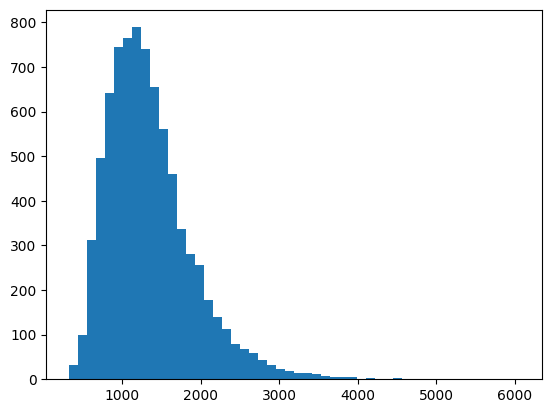

In [12]:
# check length of the text
plt.hist(df['text_len'], bins=50)

In [13]:
# set a recipe's max number of characters to 2000 as it covers most recipes
MAX_RECIPE_LENGTH=2000

df = df[df['text_len'] <= MAX_RECIPE_LENGTH]

text_data = df['formatted_recipe'].tolist()
print(f"Total recipes after filtering: {len(text_data)}")

Total recipes after filtering: 7090


In [14]:
# GPT-2's tokenizer is better for generation tasks than BERT's
tokenizer = AutoTokenizer.from_pretrained("gpt2")
# GPT-2 doesn't have a default padding token, so we set it to the EOS token
tokenizer.pad_token = tokenizer.eos_token

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [15]:
MAX_SEQ_LENGTH = 300

tokenized_outputs = tokenizer(
    text_data,
    padding="max_length",
    truncation=True,
    max_length=MAX_SEQ_LENGTH + 1, # +1 because we need to shift X and Y
    return_tensors="pt"
)

input_ids = tokenized_outputs['input_ids']

In [16]:
class RecipeGenDataset(Dataset):
    def __init__(self, tokenized_ids):
        self.ids = tokenized_ids

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        # The input X is tokens 0 to N-1
        # The target Y is tokens 1 to N
        sequence = self.ids[idx]
        x = sequence[:-1]
        y = sequence[1:]
        return x, y


In [17]:
# 4. DataLoader
dataset = RecipeGenDataset(input_ids)
# A custom collate_fn isn't strictly needed here since return_tensors="pt" already
# stacked them, but we keep the batch setup similar.
train_loader = DataLoader(dataset, batch_size=32, shuffle=True, drop_last=True)

In [18]:
import torch.nn as nn

In [19]:
# lstm

class LSTMGenerator(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_layers=2, dropout=0.2):
        super(LSTMGenerator, self).__init__()

        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        # 1. Embedding Layer
        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        # 2. LSTM Layer (batch_first=True, as noted in your A3 TODO!)
        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )

        # 3. Fully Connected Layer
        # INSTEAD of outputting 1 value (binary classification),
        # it outputs 'vocab_size' values (probabilities for the next token)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden):
        # x shape: (batch_size, seq_length)
        embeds = self.embedding(x)

        # lstm_out shape: (batch_size, seq_length, hidden_dim)
        lstm_out, hidden = self.lstm(embeds, hidden)

        # We don't just take the last hidden state like in classification.
        # We pass EVERY time step through the linear layer.
        logits = self.fc(lstm_out)

        return logits, hidden

    def init_hidden(self, batch_size, device):
        # Initializing hidden layers as you did in init_hidden
        return (torch.zeros(self.num_layers, batch_size, self.hidden_dim).to(device),
                torch.zeros(self.num_layers, batch_size, self.hidden_dim).to(device))

In [20]:
import torch.optim as optim

In [21]:
# training loop

def train_generator(model, train_loader, num_epochs=10, learning_rate=0.001):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    # use CrossEntropyLoss for multi-class classification (vocab prediction)
    # ignore the pad_token_id so the model isn't penalized for padding guesses
    criterion = nn.CrossEntropyLoss(ignore_index=tokenizer.pad_token_id)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    for epoch in range(num_epochs):
        model.train()
        train_losses = []

        # initialize hidden state for the epoch
        h = model.init_hidden(train_loader.batch_size, device)

        # wrap iterator with tqdm for consistency (like in A3)
        loop = tqdm(train_loader, desc=f"Epoch {epoch + 1}/{num_epochs}")

        for inputs, labels in loop:
            inputs, labels = inputs.to(device), labels.to(device)

            # Detach hidden states to prevent backpropagating all the way to start of epoch
            h = tuple([each.data for each in h])

            optimizer.zero_grad()

            outputs, h = model(inputs, h)

            # CrossEntropyLoss expects logits to be shape (batch_size, num_classes, seq_length)
            # or we can flatten them
            outputs_flat = outputs.view(-1, tokenizer.vocab_size)
            labels_flat = labels.view(-1)

            loss = criterion(outputs_flat, labels_flat)
            loss.backward()

            # Gradient clipping to prevent exploding gradients (Your A3 TODO)
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)

            optimizer.step()
            train_losses.append(loss.item())

            # Update progress bar
            loop.set_postfix(loss=loss.item())

        print(f"Epoch {epoch+1} Average Loss: {sum(train_losses)/len(train_losses):.4f}")



In [22]:
# Instantiate and train
vocab_size = tokenizer.vocab_size
model = LSTMGenerator(vocab_size=vocab_size, embedding_dim=256, hidden_dim=512)
train_generator(model, train_loader, num_epochs=5)

# Save the model weights to a file
torch.save(model.state_dict(), 'recipe_generator_lstm.pth')
print("Model saved successfully!")


Epoch 1/5: 100%|██████████| 221/221 [02:23<00:00,  1.54it/s, loss=5.01]


Epoch 1 Average Loss: 5.7214


Epoch 2/5: 100%|██████████| 221/221 [02:37<00:00,  1.41it/s, loss=3.75]


Epoch 2 Average Loss: 4.4599


Epoch 3/5: 100%|██████████| 221/221 [02:38<00:00,  1.39it/s, loss=3.36]


Epoch 3 Average Loss: 3.5524


Epoch 4/5: 100%|██████████| 221/221 [02:39<00:00,  1.38it/s, loss=2.53]


Epoch 4 Average Loss: 2.9097


Epoch 5/5: 100%|██████████| 221/221 [02:41<00:00,  1.37it/s, loss=2.16]


Epoch 5 Average Loss: 2.4300
Model saved successfully!


In [23]:
# 1. Recreate the empty model architecture (must match exact dimensions used in training)
loaded_model = LSTMGenerator(vocab_size=tokenizer.vocab_size, embedding_dim=256, hidden_dim=512)

# 2. Load the saved weights
loaded_model.load_state_dict(torch.load('recipe_generator_lstm.pth'))

# 3. Move to GPU and set to Evaluation Mode
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
loaded_model.to(device)
loaded_model.eval() # tells pytorch we are not training

LSTMGenerator(
  (embedding): Embedding(50257, 256)
  (lstm): LSTM(256, 512, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=512, out_features=50257, bias=True)
)

In [24]:
import torch.nn.functional as F

def generate_recipe(model, tokenizer, ingredients_list, recipe_title="My Custom Recipe", max_length=300, temperature=0.8):
    """
    Takes ingredients, formats them using our training landmarks, and generates the instructions.
    Temperature controls creativity:
        Lower (e.g., 0.3) = safer, more repetitive.
        Higher (e.g., 1.2) = creative, potentially chaotic.
    """
    model.eval()
    device = next(model.parameters()).device

    # 1. Format the "Seed" text exactly how the model saw it during training
    ingredients_str = "\n".join([f"• {ing.strip()}" for ing in ingredients_list])
    seed_text = f"📗 {recipe_title}\n🥕\n{ingredients_str}\n📝\n"

    # 2. Tokenize the seed text
    input_ids = tokenizer.encode(seed_text, return_tensors='pt').to(device)
    generated_sequence = input_ids[0].tolist()

    print("--- Generating Recipe ---")

    with torch.no_grad():
        for _ in range(max_length):
            # We must pass the sequence into the model.
            # To prevent memory errors, we only pass the last 300 tokens (our MAX_SEQ_LENGTH from training)
            seq_input = torch.tensor([generated_sequence[-300:]]).to(device)

            # Re-initialize hidden state for this forward pass
            h = model.init_hidden(1, device)

            # Get predictions
            logits, _ = model(seq_input, h)

            # We only care about the model's prediction for the *very last* token
            next_token_logits = logits[0, -1, :]

            # 3. Apply Temperature Scaling
            next_token_logits = next_token_logits / temperature

            # 4. Convert logits to probabilities using Softmax
            probs = F.softmax(next_token_logits, dim=-1)

            # 5. Sample the next token based on those probabilities
            next_token = torch.multinomial(probs, num_samples=1).item()

            # Append to our sequence
            generated_sequence.append(next_token)

            # Stop generating if the model outputs the padding/end token
            if next_token == tokenizer.eos_token_id:
                break

    # 6. Decode the final sequence back into readable text
    final_text = tokenizer.decode(generated_sequence)
    return final_text

In [25]:
# The ingredients
my_ingredients = [
    "2 cups flour",
    "1 cup sugar",
    "3 eggs",
    "1 tsp vanilla extract",
    "1/2 cup butter"
]

# Generate
recipe = generate_recipe(
    model=loaded_model,
    tokenizer=tokenizer,
    ingredients_list=my_ingredients,
    recipe_title="Vanilla Pound Cake",
    temperature=0.7 # Tweak this if the text is too weird or too boring
)

print(recipe)

--- Generating Recipe ---
📗 Vanilla Pound Cake
🥕
• 2 cups flour
• 1 cup sugar
• 3 eggs
• 1 tsp vanilla extract
• 1/2 cup butter
📝
▪︎ To begin making the Cli Style Orange Kiyali And Banana Recipe, firstly wash the vegetables along with a pressure cooker into a bowl.
▪︎ In a kadai with the oil and add the chilli powder. Mix and sesame seeds and stir until the vegetables are mushy.
▪︎ Take the oil.
▪︎ The next step is to cook the dal and cook into a minute. Make a goodil oil.
▪︎ Once the cooked dough into the oven of the dough and cover in the center to 200 C.
▪︎ Add the garlic and coriander powder. Add a little salt and salt. Set aside.
▪︎ Serve the Roasted N Curd Recipe with
▪︎ or a
▪︎ and
▪︎ or
▪︎ .
␣ the oven.
␣
▪︎ Heat a wok or
▪︎ .
␣ them with your friends.
␣ the dough and set aside for about 8 minutes.
▪︎ The next step is to the dials.
▪︎ Heat a
▪︎ and add in water. Add in the onions and cook until it becomes soft and crisp.
▪︎ Now add the oil and add the ground mixture and sa
